<div style="padding:10px;
            color:#E55604;
            margin:10px;
            font-size:130%;
            display:fill;
            border-radius:5px;
            border-style: solid;
            border-color: #FF9B50;
            background-color:#000000;
            overflow:hidden;
            font-weight:400"><b>Importing Libraries</b>
</div>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import adjusted_rand_score

# 1. Load and Clean Dataset


In [8]:
url = "../data/heart_disease.csv"

df = pd.read_csv(url)

df = df.replace("?", np.nan)
df = df.dropna()
df = df.astype(float)

X = df.iloc[:, :-1]
y = df.iloc[:, -1]
y = (y > 0).astype(int)  # Binary: 0 = no disease, 1 = disease

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. K-Means Clustering


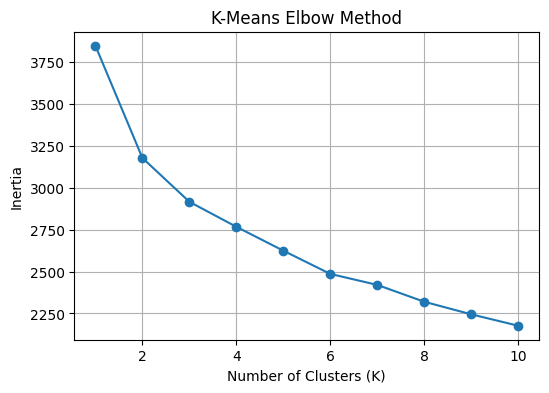

In [9]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Elbow method plot
plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Method")
plt.grid()
plt.show()

# Apply KMeans with K=2 (since we have binary labels: disease/no disease)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_kmeans = kmeans.fit_predict(X_scaled)

# 3. Hierarchical Clustering


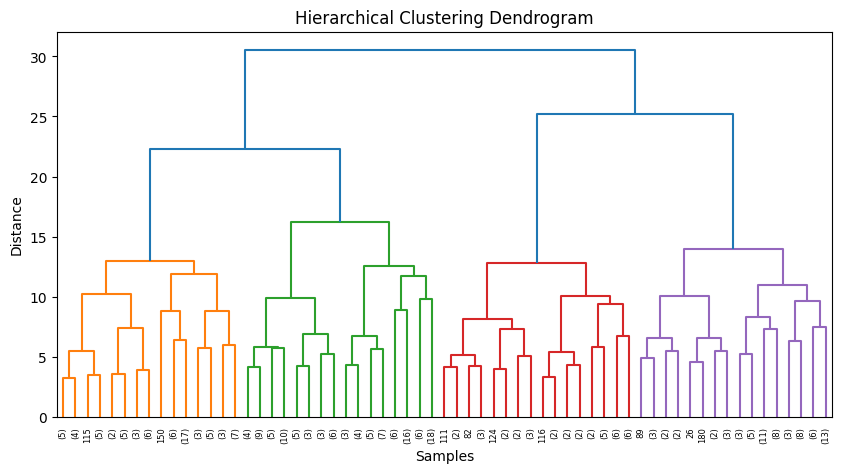

In [10]:
linked = linkage(X_scaled, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode="level", p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

# Assign clusters (cut tree at 2 clusters)
clusters_hc = fcluster(linked, t=2, criterion="maxclust")

# 4. Compare with Actual Labels


In [11]:
ari_kmeans = adjusted_rand_score(y, clusters_kmeans)
ari_hc = adjusted_rand_score(y, clusters_hc)

print("\nAdjusted Rand Index (ARI) - higher is better (1.0 = perfect match):")
print(f"K-Means ARI: {ari_kmeans:.4f}")
print(f"Hierarchical Clustering ARI: {ari_hc:.4f}")


Adjusted Rand Index (ARI) - higher is better (1.0 = perfect match):
K-Means ARI: 0.4455
Hierarchical Clustering ARI: 0.1506


# 5. Visualization (2D PCA projection for clarity)


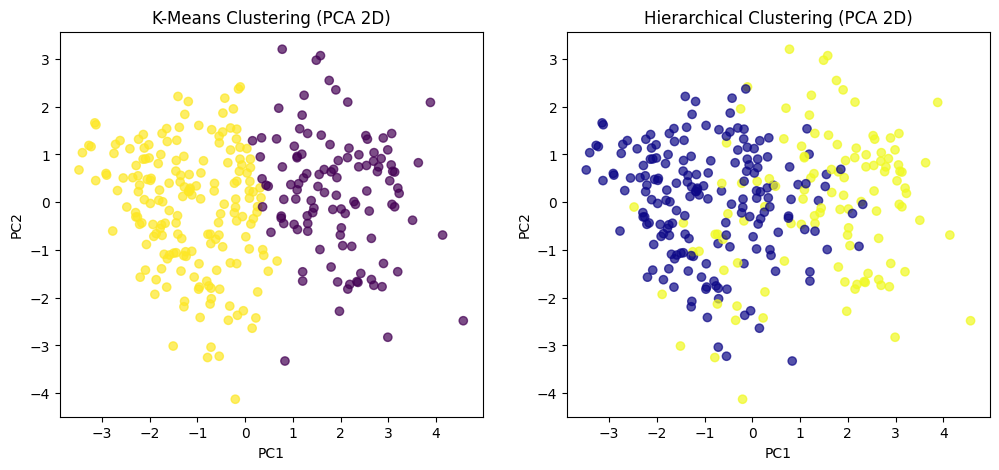

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12,5))

# KMeans plot
plt.subplot(1,2,1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters_kmeans, cmap="viridis", alpha=0.7)
plt.title("K-Means Clustering (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")

# Hierarchical plot
plt.subplot(1,2,2)
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters_hc, cmap="plasma", alpha=0.7)
plt.title("Hierarchical Clustering (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()